Classify data with KNN algorithm.

Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize
purchased and not_purchased data distribution based on age and estimated
salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the
customer will purchase a mobile or not.

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Units    14 non-null     int64
 1   Minutes  14 non-null     int64
dtypes: int64(2)
memory usage: 356.0 bytes
Index(['Units', 'Minutes'], dtype='object')
First 5 rows:
    Units  Minutes
0      1       23
1      2       29
2      3       49
3      4       64
4      4       74
Intercept: 4.161654135338296
Coefficient: 15.508771929824569
R² Score: 0.9874371980620736


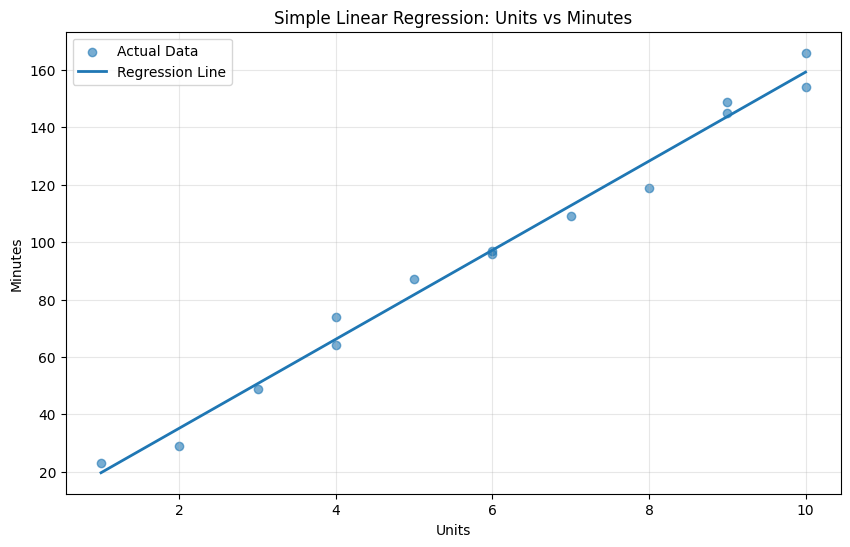

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df_lr = pd.read_csv("./Datasets/computers.csv")

# Check dataset
df_lr.info()
print(df_lr.columns)
print("First 5 rows:\n", df_lr.head())

# Features and Target
X_lr = df_lr[["Units"]].values
y_lr = df_lr["Minutes"].values

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_lr, y_lr)

# Get intercept and coefficient
intercept = lr_model.intercept_
coefficient = lr_model.coef_[0]

print(f"Intercept: {intercept}")
print(f"Coefficient: {coefficient}")

# Make predictions
y_pred_lr = lr_model.predict(X_lr)

# Calculate R² score
r2 = r2_score(y_lr, y_pred_lr)
print(f"R² Score: {r2}")

# Visualize the model
plt.figure(figsize=(10, 6))
plt.scatter(X_lr, y_lr, label='Actual Data', alpha=0.6)
plt.plot(X_lr, y_pred_lr, linewidth=2, label='Regression Line')
plt.xlabel("Units")
plt.ylabel("Minutes")
plt.title("Simple Linear Regression: Units vs Minutes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
from pathlib import Path

import matplotlib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

matplotlib.use("Agg")
import matplotlib.pyplot as plt


DATASET_CANDIDATES = [
    Path("Datasets/computer.csv"),
    Path("Datasets/computers.csv"),
]
PLOT_PATH = Path("computers_regression_plot.png")


def get_dataset_path() -> Path:
    for path in DATASET_CANDIDATES:
        if path.exists():
            return path
    raise FileNotFoundError("Neither 'Datasets/computer.csv' nor 'Datasets/computers.csv' was found.")


def main() -> None:
    dataset_path = get_dataset_path()
    data = pd.read_csv(dataset_path)

    x = data[["Units"]]
    y = data["Minutes"]

    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    intercept = model.intercept_
    coefficient = model.coef_[0]
    r_squared = r2_score(y, y_pred)

    sorted_data = data.sort_values("Units")
    x_line = sorted_data[["Units"]]
    y_line = model.predict(x_line)

    plt.figure(figsize=(8, 5))
    plt.scatter(data["Units"], y, color="steelblue", s=60, label="Actual data")
    plt.plot(x_line["Units"], y_line, color="crimson", linewidth=2, label="Regression line")
    plt.title("Simple Linear Regression using computers.csv")
    plt.xlabel("Units")
    plt.ylabel("Minutes")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150)

    print(f"Dataset used               : {dataset_path}")
    print(f"Intercept                  : {intercept:.4f}")
    print(f"Coefficient (slope)        : {coefficient:.4f}")
    print(f"Coefficient of Determination (R^2): {r_squared:.4f}")
    print(f"Plot saved to              : {PLOT_PATH.resolve()}")


if __name__ == "__main__":
    main()


Dataset used               : Datasets\computers.csv
Intercept                  : 4.1617
Coefficient (slope)        : 15.5088
Coefficient of Determination (R^2): 0.9874
Plot saved to              : C:\Ml_class Practical\computers_regression_plot.png


## Classify data with KNN algorithm.

Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize
purchased and not_purchased data distribution based on age and estimated
salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the
customer will purchase a mobile or not.

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


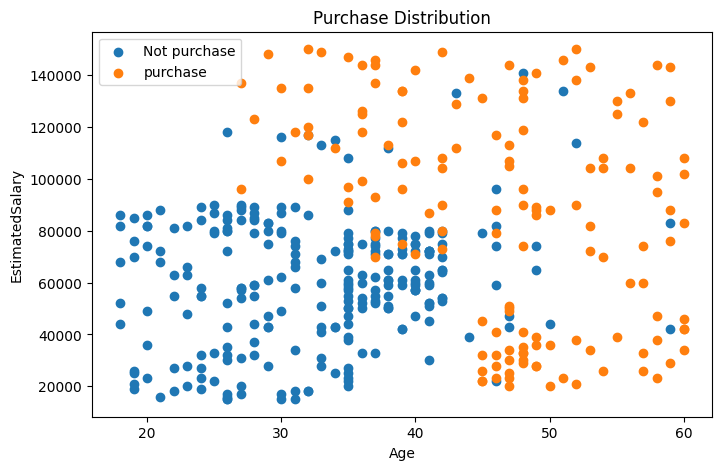

accuracy_score: 0.925
Customer will PURCHASE mobile


In [33]:
%matplotlib inline
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv("./Datasets/mobile.csv")
print(df.head())

X=df[["Age","EstimatedSalary"]]
y=df["Purchased"]

plt.figure(figsize=(8,5))

plt.scatter(X[y==0]["Age"],X[y==0]["EstimatedSalary"], label="Not purchase")

plt.scatter(X[y==1]["Age"],X[y==1]["EstimatedSalary"], label="purchase")

plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.title("Purchase Distribution")
plt.legend()
plt.show()


X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2, random_state=42)

Scaler =MinMaxScaler()
X_train=Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

y_pred= model.predict(X_test)

accuracy =accuracy_score(y_test,y_pred)
print("accuracy_score:", accuracy)

new_data = pd.DataFrame([[30, 50000]], columns=["Age", "EstimatedSalary"])
new_data_scaled = Scaler.transform(new_data)

result = model.predict(new_data_scaled)


if prediction[0]==1:
        print("Customer will PURCHASE mobile")
else:
    print("Customer will NOT purchase mobile")

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

df= pd.read_csv("./Datasets/mobile.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
df.dtypes

Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [6]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [21]:
X =df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

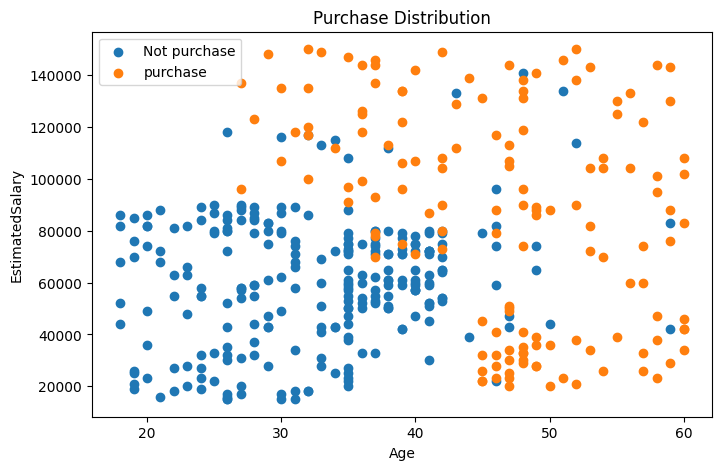

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X[y==0]["Age"],X[y==0]["EstimatedSalary"],label="Not purchase")
plt.scatter(X[y==1]["Age"],X[y==1]["EstimatedSalary"],label="purchase")
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.title("Purchase Distribution")
plt.legend()
plt.show()

In [29]:
X_train ,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
Scaler = MinMaxScaler()
X_train= Scaler.fit_transform(X_train)
X_test= Scaler.transform(X_test)

In [31]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [32]:
y_pred= model.predict(X_test)

accuracy =accuracy_score(y_test,y_pred)
print("accuracy_score:", accuracy)

accuracy_score: 0.925


In [41]:
new_Data = pd.DataFrame([[30,50000]], columns=["Age","EstimatedSalary"])
new_Data_scled =Scaler.transform(new_Data)

result=model.predict(new_Data_scled)

if[0]==1:
    print("purchase")
else:
    print("not purchase")

not purchase


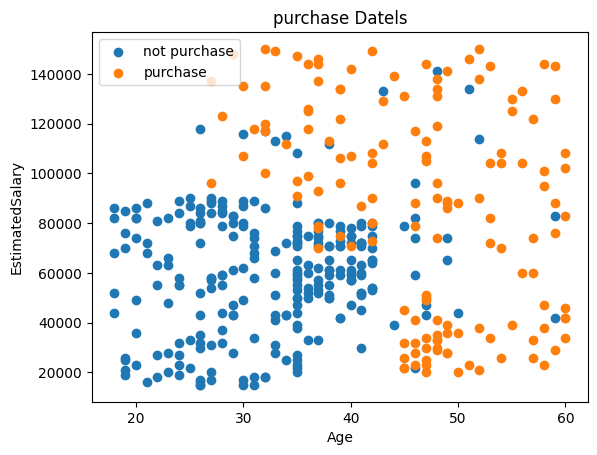

accuracy_score: 0.925
y


In [57]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

df =pd.read_csv("./Datasets/mobile.csv")
df.head()

X=df[["Age","EstimatedSalary"]]
y=df["Purchased"]

plt.scatter(X[y==0]["Age"],X[y==0]["EstimatedSalary"],label="not purchase")
plt.scatter(X[y==1]["Age"],X[y==1]["EstimatedSalary"],label="purchase")

plt.title("purchase Datels")
plt.legend()
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.show()

X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

Scaler =MinMaxScaler()
X_train=Scaler.fit_transform(X_train)
X_test =Scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

y_pred= model.predict(X_test)

accuracy =accuracy_score(y_test,y_pred)
print("accuracy_score:", accuracy)

new_Data = pd.DataFrame([[30,50000]],columns=["Age","EstimatedSalary"])
new_Data_scaler=Scaler.transform(new_Data)

result=model.predict(new_data_scaled)
if[0]==1:
    print("x")
else:
    print("y")